# Libraries

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score
import joblib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

# Upload dataset

In [7]:
df = pd.read_excel(r'C:\Users\Renata Pensin\Desktop\ic_victor\toy_problem\dataset_lambda_from_pce.xlsx') # Prof. Wander PC
features = ['R', 'S', 'Time']
targets = ['lambda1', 'lambda2'] 
x = df[features]
y = df[targets]

# Split data

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# scaler = StandardScaler()
# x_train_scaled = scaler.fit_transform(x_train)
# x_test_scaled = scaler.transform(x_test)

# Train MLP model

In [9]:
regr_nn = MLPRegressor(hidden_layer_sizes=(100, 100), activation='relu', solver='adam', max_iter=2000, random_state=42)
# regr_nn.fit(X_train_scaled, y_train)
regr_nn.fit(x_train, y_train)

MLPRegressor(hidden_layer_sizes=(100, 100), max_iter=2000, random_state=42)

# Save MLP model

In [10]:
joblib.dump(regr_nn, 'ann_model_lambda.joblib')
# joblib.dump(scaler, 'scaler_ann.joblib')

['ann_model_lambda.joblib']

# Train and test score

In [11]:
y_pred_nn = regr_nn.predict(x_test)
score_l1 = r2_score(y_test['lambda1'], y_pred_nn[:, 0])
score_l2 = r2_score(y_test['lambda2'], y_pred_nn[:, 1])
print(f"R² Lambda 1: {score_l1:.4f}")
print(f"R² Lambda 2: {score_l2:.4f}")

R² Lambda 1: 0.9976
R² Lambda 2: 0.9844


### Data

In [ ]:
# Evolution Parameters
r_val = 5.09
s_val = 1.80
time_range = np.linspace(0, 100, 200) # 0 a 100 anos (Linha Suave)

# DataFrame para previsão
df_evolution = pd.DataFrame({
    'R': [r_val] * len(time_range),
    'S': [s_val] * len(time_range),
    'Time': time_range
})

# Predict
y_evol_pred = regr_nn.predict(df_evolution)

# Data
data_l1 = {'x': time_range, 'y': y_evol_pred[:, 0]}
data_l2 = {'x': time_range, 'y': y_evol_pred[:, 1]}
data_list = [data_l1, data_l2]


### Graph

<>:55: SyntaxWarning: invalid escape sequence '\l'
<>:55: SyntaxWarning: invalid escape sequence '\l'
<>:55: SyntaxWarning: invalid escape sequence '\l'
<>:55: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Renata Pensin\AppData\Local\Temp\ipykernel_33008\640884112.py:55: SyntaxWarning: invalid escape sequence '\l'
  labels_y = ['$\lambda_1$', '$\lambda_2$']
C:\Users\Renata Pensin\AppData\Local\Temp\ipykernel_33008\640884112.py:55: SyntaxWarning: invalid escape sequence '\l'
  labels_y = ['$\lambda_1$', '$\lambda_2$']


Saving graph to z_temporal_evolution_ann_with_points_en.png...


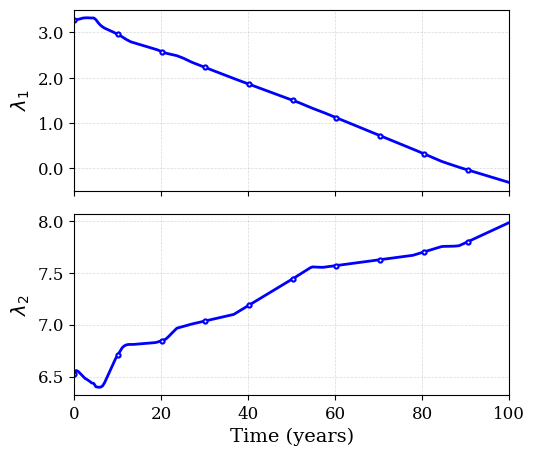

In [ ]:
dpi = 600
name = 'temporal_evolution_ann_with_points'

# Dimensões
b_cm, h_cm = 14, 12 
inches_to_cm = 1 / 2.54
b_input_total, h_input = b_cm * inches_to_cm, h_cm * inches_to_cm

# Eixos e Labels
label_x = 'Time (years)'   
size_label = 14
color_label = 'black'      
size_axis = 12
color_axis = 'black'

# Linha e Marcadores
size_line = 2
style_line = '-'
color_line = 'blue'

# Marker
marker = 'o'
size_marker = 3
color_marker = 'blue' 
mark_freq = 20  

# Y-Labels
labels_y = ['$\lambda_1$', '$\lambda_2$']

# Grid
on_or_off = True
line_width_grid = 0.5
alpha_grid = 0.3
style_grid = '--'
color_grid = 'gray'

# Plot
fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(b_input_total, h_input))

for i, ax in enumerate(axes):
    dataset = data_list[i]
    
    ax.plot(dataset['x'], dataset['y'],
            marker=marker, 
            markersize=size_marker,
            markevery=mark_freq,       # <--- O TRUQUE ESTÁ AQUI
            markerfacecolor='white',   # Miolo branco (estilo científico comum)
            markeredgecolor=color_line,# Borda da cor da linha
            markeredgewidth=1.5,
            linewidth=size_line, 
            linestyle=style_line, 
            color=color_line)
    
    ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)

    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
    # Label Y
    ax.set_ylabel(labels_y[i], fontsize=size_label, color=color_label)
    
    # Grid
    ax.grid(on_or_off, which='both', linestyle=style_grid, linewidth=line_width_grid, color=color_grid, alpha=alpha_grid)

# Label X 
axes[-1].set_xlabel(label_x, fontsize=size_label, color=color_label)
axes[-1].set_xlim(0, 100)

plt.tight_layout()

# Save Figure
filename = f'z_{name}_en.png'
print(f"Saving graph to {filename}...")
fig.savefig(filename, dpi=dpi, bbox_inches='tight')
plt.show()